# Đề 7: So sánh ảnh hưởng của hàm kích hoạt đến quá trình huấn luyện mạng nơ-ron

**Mục tiêu:** Khảo sát thực nghiệm vai trò của các hàm kích hoạt khác nhau (Sigmoid, Tanh, ReLU, Leaky ReLU) đối với tốc độ học và hiệu suất cuối cùng của mạng nơ-ron

---
## Dữ liệu và Môi trường

Tập dữ liệu: **MNIST** (phân loại chữ số viết tay).
Lý do:
- Kích thước vừa đủ (ảnh 28x28 pixel, 1 kênh màu -> duỗi thẳng thành Vector 784 chiều), giúp huấn luyện nhanh trên CPU hoặc GPU phổ thông.
- Với tính chất dữ liệu không quá phức tạp nhưng cũng không quá đơn giản, các hiện tượng sụt giảm hiệu năng do Vanishing Gradient hay Dying ReLU sẽ được thể hiện cực kỳ rõ ràng khi ta tăng độ sâu của mạng.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
import time
warnings.filterwarnings('ignore')

# Matplotlib config
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# CẤU HÌNH
SEEDS = [42, 123, 456]          # 3 seed để báo cáo mean ± std
BATCH_SIZE = 128
EPOCHS = 50
LR_DEFAULT = 0.01
MOMENTUM = 0.9

# Kiến trúc mạng
SHALLOW_LAYERS = 3              # Mạng nông: 3 hidden layers
SHALLOW_HIDDEN = 256
DEEP_LAYERS = 8                 # Mạng sâu: 8 hidden layers
DEEP_HIDDEN = 256
INPUT_SIZE = 784                # 28 x 28
OUTPUT_SIZE = 10                # 10 chữ số

# 4 hàm kích hoạt: Sigmoid, Tanh, ReLU, Leaky ReLU
ACTIVATIONS = {
    'Sigmoid': nn.Sigmoid,
    'Tanh': nn.Tanh,
    'ReLU': nn.ReLU,
    'Leaky ReLU': lambda: nn.LeakyReLU(0.01),
}
COLORS = {
    'Sigmoid':    '#e74c3c',
    'Tanh':       '#3498db',
    'ReLU':       '#2ecc71',
    'Leaky ReLU': '#f39c12',
}

In [3]:
# LOAD MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Chia 10% train -> validation (6.000 mẫu)
num_train = len(train_dataset)
indices = list(range(num_train))
np.random.seed(42)
np.random.shuffle(indices)

val_split = int(0.1 * num_train)
val_indices   = indices[:val_split]
train_indices = indices[val_split:]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler   = SubsetRandomSampler(val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader   = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=val_sampler)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_indices):,} mẫu ({len(train_loader)} batch)')
print(f'Val:   {len(val_indices):,} mẫu ({len(val_loader)} batch)')
print(f'Test:  {len(test_dataset):,} mẫu ({len(test_loader)} batch)')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]

Train: 54,000 mẫu (422 batch)
Val:   6,000 mẫu (47 batch)
Test:  10,000 mẫu (79 batch)


## Yêu cầu 2: Cơ sở lý thuyết cần trình bày

### 2.1. Các hàm kích hoạt phổ biến: Sigmoid, Tanh, ReLU, Leaky ReLU

**1. Hàm Sigmoid**
- **Đặc điểm:** Hàm Sigmoid biến đổi giá trị đầu vào thành một khoảng giá trị $\in (0, 1)$. Trong quá khứ, hàm này thường được sử dụng do có dạng đồ thị mô phỏng tốt "tỷ lệ kích hoạt" (firing rate) của nơ-ron sinh học.
- **Nhược điểm (Vấn đề toán học):**
  - *Không Zero-centered:* Đầu ra luôn mang giá trị dương, dẫn đến việc gradient của các trọng số ($W$) liên quan bắt buộc phải cùng dấu. Điều này khiến thuật toán tối ưu hóa (Gradient Descent) bị ép phải cập nhật theo đường zig-zag, làm giảm đáng kể tốc độ hội tụ.
  - *Bão hòa (Saturation):* Ở hai thái cực vô cùng, đạo hàm của Sigmoid tiến rất nhanh về $0$. Điều này trực tiếp gây ra hiện tượng triệt tiêu đạo hàm (Vanishing Gradient), khiến quá trình cập nhật ở mạng nơ-ron sâu bị đóng băng. Phép tính hàm mũ $e^{-x}$ cũng đòi hỏi chi phí tính toán cao.

**2. Hàm Tanh (Tang Hyperbolic)**
- **Đặc điểm:** Là phiên bản co giãn và tịnh tiến của Sigmoid nhằm đưa miền giá trị về khoảng $(-1, 1)$.
- **Ưu điểm:** Mang tính chất **Zero-centered** (đối xứng qua gốc tọa độ). Đặc tính này giải quyết triệt để sự cố cập nhật zig-zag, giúp mô hình hội tụ ổn định hơn so với Sigmoid.
- **Nhược điểm:** Tương tự Sigmoid, hàm Tanh vẫn gặp phải sự bão hòa đạo hàm ở hai vùng đuôi (khi $|x|$ lớn). Do đó, bài toán Vanishing Gradient trên mạng sâu vẫn không được khắc phục.

**3. Hàm ReLU (Rectified Linear Unit)**
- **Đặc điểm:** Áp dụng phép toán phi tuyến đơn giản $f(x) = \max(0, x)$.
- **Ưu điểm:** Khắc phục hoàn toàn sự bão hòa đạo hàm ở miền dương (đạo hàm luôn là hằng số $1$ khi $x > 0$). Nhờ tín hiệu lỗi được bảo toàn khi truyền ngược, ReLU vượt qua trở ngại Vanishing Gradient và đem lại tốc độ hội tụ thực nghiệm nhanh hơn khoảng 6 lần so với Sigmoid/Tanh.
- **Nhược điểm (Hội chứng Nơ-ron chết - Dying ReLU):** Điểm yếu chí mạng của ReLU nằm ở chính sự đơn giản của nó: vùng âm có đạo hàm triệt tiêu tuyệt đối bằng $0$. Nếu tốc độ học (Learning Rate) quá lớn, một lần cập nhật mạnh có thể đẩy nơ-ron ra khỏi phân bố dữ liệu (Data Cloud). Khi đó, $z = Wx+b$ luôn âm, đạo hàm vĩnh viễn bằng $0$. Hậu quả là nơ-ron bị "tê liệt", không thể tự cập nhật trọng số và chính thức "chết" trong suốt phần còn lại của quá trình huấn luyện. Về mặt thực hành, điều này đồng nghĩa với việc đầu ra của nơ-ron luôn bị ép bằng $0$ đối với mọi mẫu dữ liệu trong Dataset (không đóng góp bất kỳ thông tin nào cho quá trình lan truyền xuôi).

**4. Từ nhược điểm Dying ReLU kể trên, 2 luồng giải pháp chính đã được ra đời**: một là can thiệp trực tiếp vào cấu trúc toán học của hàm số (Leaky ReLU), hai là sử dụng thủ thuật khi khởi tạo mạng (Bias dương).

**Giải pháp 1: Hàm Leaky ReLU (Can thiệp cấu trúc hàm)**
- **Đặc điểm:** Là biến thể mở rộng của ReLU. Thay vì ép giá trị âm về $0$, Leaky ReLU duy trì một độ dốc "rò rỉ" rất nhỏ (ví dụ $\alpha = 0.01$) tại miền âm: $f(x) = \max(0.01x, x)$.
- **Ưu điểm:** Bằng cách này, đạo hàm ở miền âm không bao giờ bị triệt tiêu hoàn toàn. Ngay cả khi một nơ-ron không may rơi vào trạng thái $x < 0$, nó vẫn sẽ nhận được một lượng gradient nhỏ (non-zero) len lỏi truyền về. Lượng gradient này đóng vai trò như một "phao cứu sinh", giúp nơ-ron liên tục tự tinh chỉnh trọng số để có cơ hội ngoi lên vùng dương và quay trở lại trạng thái kích hoạt.

**Giải pháp 2: Khởi tạo Bias dương cho ReLU nguyên bản**
Nếu hệ thống bắt buộc phải sử dụng hàm ReLU nguyên bản (ví dụ để tối ưu tuyệt đối tốc độ tính toán phần cứng), chúng ta vẫn có cách để hạn chế tỷ lệ nơ-ron chết ngay từ vạch xuất phát.
Tại thời điểm khởi tạo mạng, thay vì để Bias bằng $0$, các kỹ sư thường **thiết lập Bias ban đầu bằng một hằng số dương nhỏ** (VD: $b = 0.01$). Khi đó, tổng tín hiệu $z = Wx + b$ có xu hướng lớn hơn $0$. Thủ thuật này giống như việc "bật sẵn công tắc" cho các nơ-ron trong những epoch đầu tiên, đảm bảo chúng đều ở trạng thái hoạt động (Active) để kịp thời nhận gradient và tự điều chỉnh quỹ đạo $W$ về hướng an toàn trước khi có nguy cơ rơi xuống vùng âm.

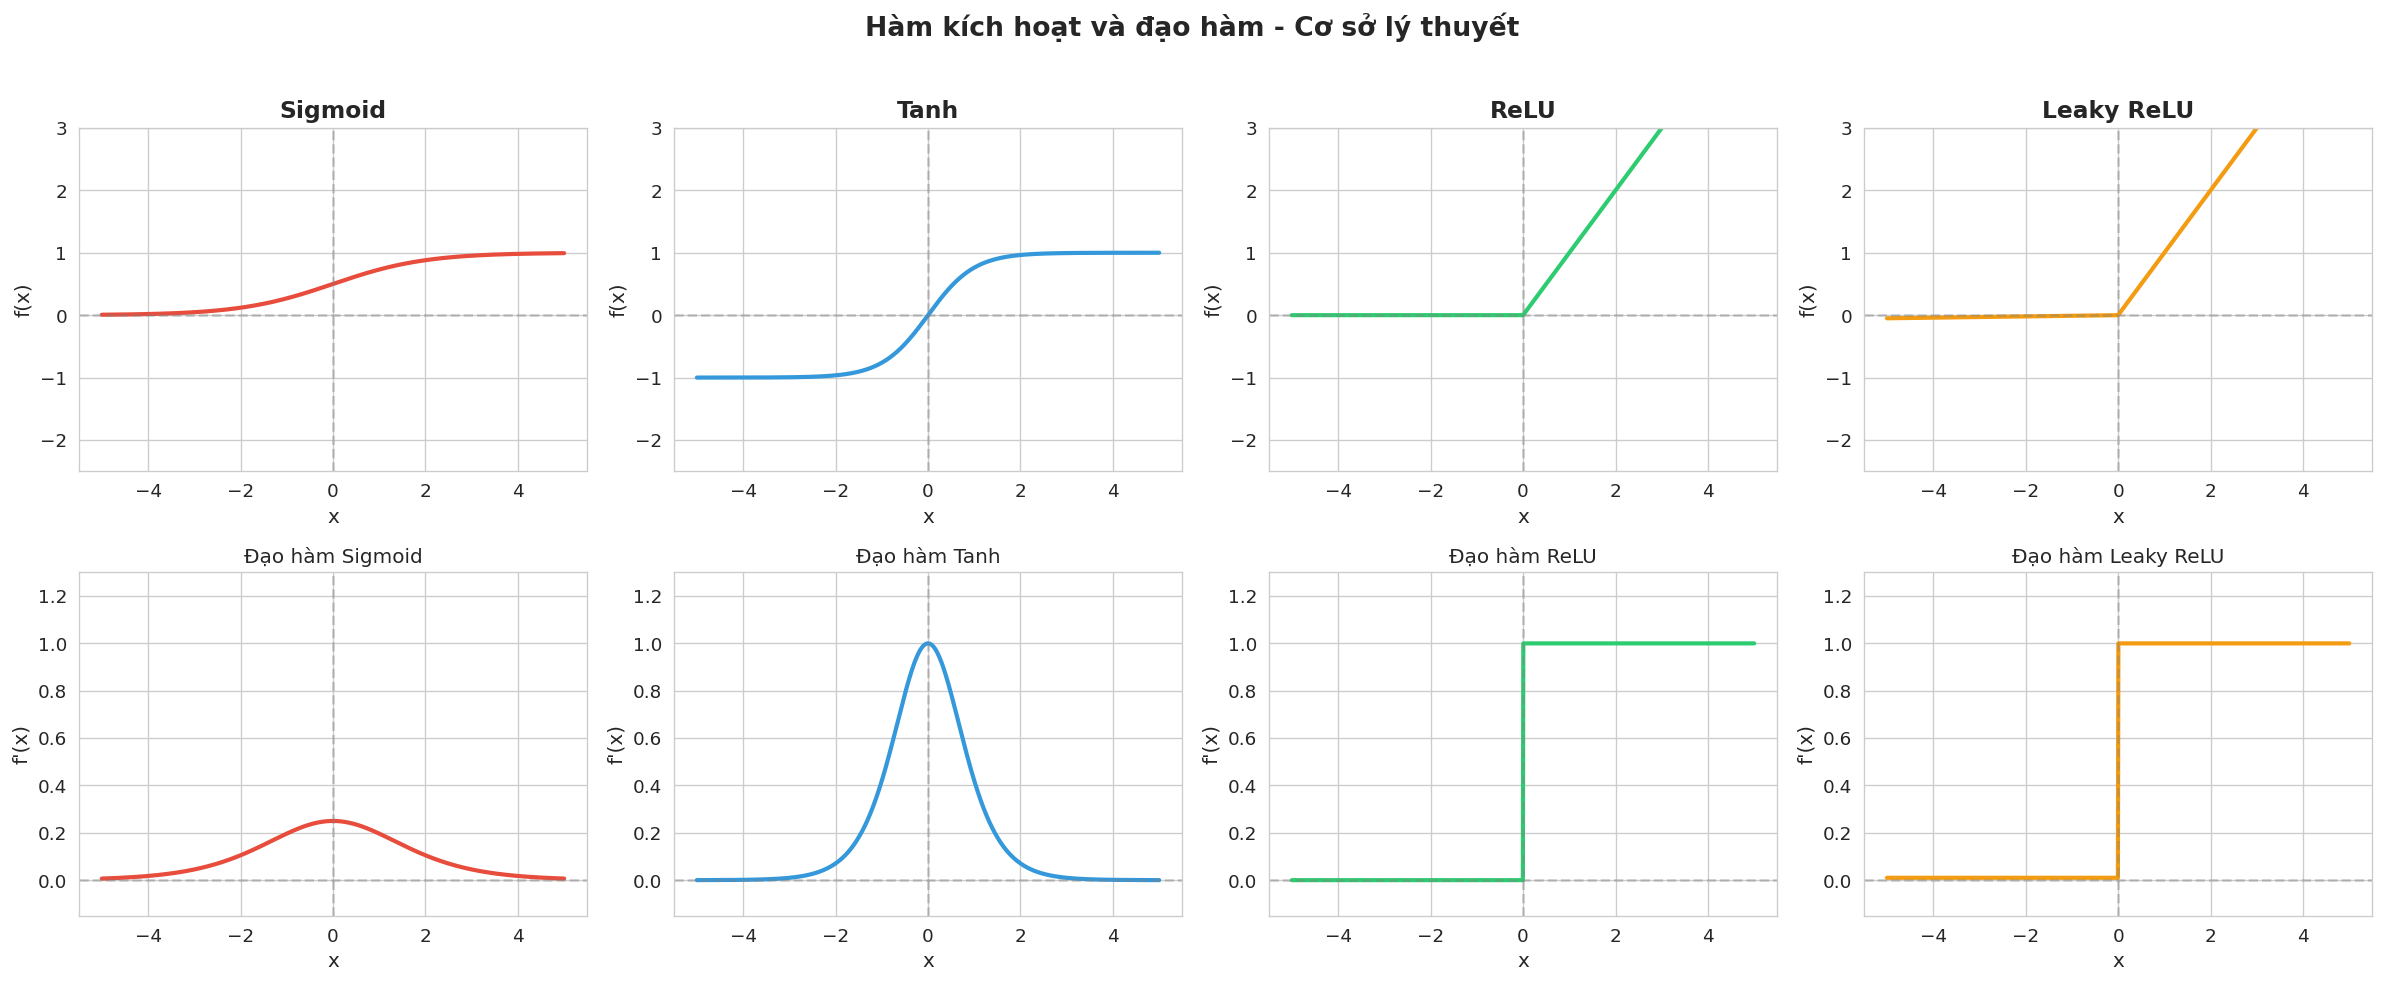

In [4]:
# Xây dựng hàm kích hoạt và đạo hàm thủ công bằng numpy:
x_theory = np.linspace(-5, 5, 1000)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid_np(x)
    return s * (1.0 - s)

def tanh_np(x):
    return np.tanh(x)

def tanh_grad(x):
    return 1.0 - np.tanh(x) ** 2

def relu_np(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def leaky_relu_np(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_grad(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)

theory_funcs = {
    'Sigmoid':    (sigmoid_np,    sigmoid_grad),
    'Tanh':       (tanh_np,       tanh_grad),
    'ReLU':       (relu_np,       relu_grad),
    'Leaky ReLU': (leaky_relu_np, leaky_relu_grad),
}
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (name, (fn, dfn)) in enumerate(theory_funcs.items()):
    color = list(COLORS.values())[i]
    axes[0, i].plot(x_theory, fn(x_theory), color=color, linewidth=2.5)
    axes[0, i].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
    axes[0, i].axvline(x=0, color='gray', linestyle='--', alpha=0.4)
    axes[0, i].set_title(f'{name}', fontweight='bold', fontsize=14)
    axes[0, i].set_xlabel('x')
    axes[0, i].set_ylabel('f(x)')
    axes[0, i].set_ylim(-2.5, 3)
    axes[1, i].plot(x_theory, dfn(x_theory), color=color, linewidth=2.5)
    axes[1, i].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
    axes[1, i].axvline(x=0, color='gray', linestyle='--', alpha=0.4)
    axes[1, i].set_title(f"Đạo hàm {name}", fontsize=12)
    axes[1, i].set_xlabel('x')
    axes[1, i].set_ylabel("f'(x)")
    axes[1, i].set_ylim(-0.15, 1.3)
fig.suptitle('Hàm kích hoạt và đạo hàm - Cơ sở lý thuyết', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_activation_theory.png', dpi=150, bbox_inches='tight')
plt.show()

**Bảng so sánh lý thuyết (Tổng hợp):**

| Hàm |   Công thức   | Miền giá trị | Đạo hàm max | Đạo hàm tại vùng bão hòa | Zero-centered? |
|---|---|---|---|---|---|
| **Sigmoid** | $\frac{1}{1 + e^{-x}}$ | $(0, 1)$ | $0.25$ | $\approx 0$ | Không |
| **Tanh** | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$ | $1.0$ | $\approx 0$ | Có |
| **ReLU** | $\max(0, x)$ | $[0, +\infty)$ | $1.0$ (khi $x>0$) | $0$ (khi $x<0$) | Không |
| **Leaky ReLU** | $\max(0.01x, x)$ | $(-\infty, +\infty)$ | $1.0$ (khi $x>0$) | $0.01$ (khi $x<0$) | Không |

---


### 2.2. Hiện tượng Vanishing Gradient và nguyên nhân gây ra

**Hiện tượng Vanishing Gradient (Triệt tiêu đạo hàm)** xảy ra khi gradient trở nên cực kỳ nhỏ ($\approx 0$) trong quá trình lan truyền ngược, khiến các lớp đầu của mạng "ngừng học".

**Nguyên nhân (Chain Rule):**
Theo quy tắc dây chuyền, gradient ở các lớp đầu là tích của nhiều đạo hàm từ các lớp sau:
$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(L)}} \cdot \prod_{k=l}^{L-1} \frac{\partial a^{(k+1)}}{\partial a^{(k)}}$$
Với các hàm như **Sigmoid** (đạo hàm tối đa $0.25$) và **Tanh** (đạo hàm tiến về $0$ ở vùng bão hòa), việc nhân liên tiếp nhiều số nhỏ hơn $1$ sẽ làm gradient suy giảm theo cấp số nhân (ví dụ: $0.25^{10} \approx 9.54 \times 10^{-7}$).

**Hậu quả:** Trọng số các lớp đầu không được cập nhật. Mạng càng sâu, hiện tượng càng nghiêm trọng, giải thích lý do Sigmoid/Tanh thường thất bại trên mạng nhiều lớp (như sẽ thấy ở phần thực nghiệm mạng sâu).

---

### 2.3. Vai trò của hàm kích hoạt trong tính phi tuyến của mạng

*Tại sao mạng nơ-ron bắt buộc phải có hàm kích hoạt phi tuyến?*

**1. Chống sụp đổ về mô hình tuyến tính:**
Nếu không có hàm kích hoạt, tích của nhiều lớp ma trận trọng số xếp chồng lên nhau cũng chỉ tương đương với một ma trận duy nhất ($\hat{y} = W^{(L)} \dots W^{(1)} x = W_{\text{total}} x$). Khi đó, mô hình sâu 100 lớp cũng vô dụng như 1 lớp.

**2. Bẻ cong không gian & Cổng lọc thông tin (Gating):**
Hàm kích hoạt cho phép tạo ra ranh giới phân định phi tuyến phức tạp. Đồng thời, mỗi hàm hoạt động như một "cổng lọc" quy định trực tiếp hành vi gradient:
- **Sigmoid / Tanh ("Cổng mềm"):** Nén đầu ra vào khoảng hẹp, gây bão hòa đạo hàm ở 2 đầu -> Triệt tiêu đạo hàm (Vanishing Gradient).
- **ReLU / Leaky ReLU ("Cổng cứng"):** Cho phép tín hiệu đi qua với đạo hàm không đổi, giúp bảo toàn gradient truyền ngược -> Tránh được Vanishing Gradient (nhưng ReLU thuần có rủi ro nơ-ron "chết").

> *Hiểu được cơ chế Gating của từng hàm là chìa khóa để lý giải kết quả khác biệt về tốc độ hội tụ và độ chính xác ở các Thực nghiệm bên dưới.*

## Yêu cầu cài đặt cơ bản
### 3.1. Xây dựng một kiến trúc mạng MLP cố định, chỉ thay đổi hàm kích hoạt giữa các thực nghiệm

In [5]:
class MLP(nn.Module):
    """Định nghĩa tham số:
        input_size:        Kích thước input (784 cho MNIST)
        hidden_size:       Số neuron mỗi hidden layer
        num_hidden_layers: Số hidden layers
        output_size:       Số lớp đầu ra (10)
        activation_cls:    Callable tạo activation (vd: nn.ReLU)
    """
    def __init__(self, input_size, hidden_size, num_hidden_layers, output_size, activation_cls):
        super().__init__()
        self.activation = activation_cls()
        layers = []
        # Input -> first hidden
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(activation_cls())
        # Hidden -> Hidden
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation_cls())
        # Last hidden -> output (không có activation)
        layers.append(nn.Linear(hidden_size, output_size))
        self.layers = layers
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                if isinstance(self.activation, (nn.Sigmoid, nn.Tanh)):
                    nn.init.xavier_uniform_(layer.weight)
                else:
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

# TEST
test_model = MLP(784, 256, 3, 10, nn.ReLU)
print(test_model)
print(f'-> Tổng tham số: {sum(p.numel() for p in test_model.parameters()):,}')
del test_model

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)
-> Tổng tham số: 335,114


### Thiết lập các hàm Huấn luyện và Đánh giá (Training & Evaluation Pipeline)

**1. Hàm get_gradient_stats(model):**
- **Mục đích:** Trích xuất và thống kê phân phối của gradient tại từng lớp ẩn. Đây là công cụ đo lường thực nghiệm quan trọng nhất để chứng minh hiện tượng Vanishing Gradient.
- **Cơ chế hoạt động:** Hàm quét qua toàn bộ đồ thị tính toán của mô hình (thông qua model.named_parameters()). Đối với các ma trận trọng số $W$ có lưu trữ đạo hàm (param.grad), hàm sẽ trích xuất tensor gradient và tính toán các đại lượng thống kê mô tả (như trung bình trị tuyệt đối, độ lệch chuẩn, giá trị cực đại) nhằm đánh giá mức độ suy giảm tín hiệu theo chiều sâu của mạng.

**2. Hàm train_one_epoch(model, loader, criterion, optimizer, device):**
- **Mục đích:** Thực thi quá trình tối ưu hóa trọng số trên tập dữ liệu huấn luyện (Training Set) trong phạm vi một kỷ nguyên (epoch).
- **Cơ chế hoạt động:**
  - Tại mỗi mini-batch, mô hình thực hiện quá trình lan truyền xuôi (Forward Pass) để tính giá trị hàm mất mát (Loss), sau đó kích hoạt lan truyền ngược (Backward Pass) thông qua phương thức loss.backward() để tính toán gradient theo quy tắc dây chuyền (Chain Rule).
  - Trọng số được cập nhật tự động bằng optimizer.step().
  - **Điểm lưu ý:** Tại mini-batch cuối cùng của epoch, hệ thống sẽ gọi hàm get_gradient_stats *ngay trước* khi bước cập nhật trọng số diễn ra. Điều này nhằm bắt giữ chính xác trạng thái thuần túy của đạo hàm ở thời điểm hiện tại để phục vụ mục đích phân tích.

**3. Hàm evaluate(model, loader, criterion, device):**
- **Mục đích:** Đo lường hiệu năng tổng quát hóa (generalization) của mô hình trên tập kiểm định/đánh giá (Validation/Test Set).
- **Cơ chế hoạt động:** Mô hình được chuyển sang trạng thái suy diễn (model.eval()). Đồng thời, ngữ cảnh torch.no_grad() được kích hoạt nhằm vô hiệu hóa hoàn toàn cơ chế tự động lấy đạo hàm (Autograd). Việc đóng băng đồ thị tính toán này không chỉ ngăn chặn rò rỉ thông tin cập nhật trọng số, mà còn tối ưu hóa tài nguyên bộ nhớ và đẩy nhanh tốc độ tính toán phần cứng.

In [6]:
# Hàm train, evaluate, thu thập gradient

def get_gradient_stats(model):
    # Lấy thống kê gradient (mean |grad|, std) của weight tại mỗi Linear layer
    stats = []
    layer_idx = 0
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad = param.grad.data
            stats.append({
                'layer_idx': layer_idx,
                'name':      name,
                'mean_abs':  grad.abs().mean().item(),
                'std':       grad.std().item(),
                'max_abs':   grad.abs().max().item(),
                'norm':      grad.norm().item(),
            })
            layer_idx += 1
    return stats


def train_one_epoch(model, loader, criterion, optimizer, device):
    # Train 1 epoch. Thu thập gradient stats tại batch cuối
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    grad_stats = None
    num_batches = len(loader)

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Thu thập gradient tại batch cuối TRƯỚC optimizer.step()
        if batch_idx == num_batches - 1:
            grad_stats = get_gradient_stats(model)

        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += data.size(0)

    return total_loss / total, correct / total, grad_stats


def evaluate(model, loader, criterion, device):
    # Đánh giá model trên tập validation/test
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += data.size(0)

    return total_loss / total, correct / total

In [7]:
def run(activation_name, num_hidden_layers, hidden_size, seed, epochs=EPOCHS, lr=LR_DEFAULT):
    # Cố định seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # Tạo model
    act_cls = ACTIVATIONS[activation_name]
    model = MLP(INPUT_SIZE, hidden_size, num_hidden_layers, OUTPUT_SIZE, act_cls).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=MOMENTUM)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'gradient_stats': [],
    }

    t0 = time.time()
    for epoch in range(epochs):
        train_loss, train_acc, grad_stats = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['gradient_stats'].append(grad_stats)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | '
                  f'Loss: {train_loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | '
                  f'Val Acc: {val_acc:.4f}')
    elapsed = time.time() - t0

    test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

    # Đo epoch hội tụ ở 3 mức: 95%, 97%, 99% của val_acc tối đa
    max_val_acc = max(history['val_acc'])
    def get_conv_epoch(pct):
        threshold = (pct / 100.0) * max_val_acc
        return next((i + 1 for i, acc in enumerate(history['val_acc']) if acc >= threshold), epochs)

    conv_95 = get_conv_epoch(95)
    conv_97 = get_conv_epoch(97)
    conv_99 = get_conv_epoch(99)

    print(f'  -> Test Acc: {test_acc:.4f} | '
          f'Epoch (95%|97%|99% max_acc): {conv_95}|{conv_97}|{conv_99} | '
          f'Thời gian: {elapsed:.1f}s')

    return {
        'activation': activation_name,
        'num_layers': num_hidden_layers,
        'hidden_size': hidden_size,
        'seed': seed,
        'lr': lr,
        'epochs': epochs,
        'history': history,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'max_val_acc': max_val_acc,
        'conv_95': conv_95,
        'conv_97': conv_97,
        'conv_99': conv_99,
        'train_time': elapsed,
        'model': model,
    }


def run_multi_seed(activation_name, num_hidden_layers, hidden_size, seeds=SEEDS, epochs=EPOCHS, lr=LR_DEFAULT):
    print(f'\n{activation_name.upper()}:')
    results = []
    for idx, seed in enumerate(seeds):
        print(f'{idx+1}. {num_hidden_layers} layers | hidden={hidden_size} | lr={lr} | seed={seed}')
        result = run(activation_name, num_hidden_layers, hidden_size, seed, epochs, lr)
        results.append(result)

    test_accs = [r['test_acc'] for r in results]
    c95 = [r['conv_95'] for r in results]
    c97 = [r['conv_97'] for r in results]
    c99 = [r['conv_99'] for r in results]
    times = [r['train_time'] for r in results]

    print(f'--> Trung bình: Test Acc = {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f} | '
          f'Epoch (95|97|99) = {np.mean(c95):.1f}|{np.mean(c97):.1f}|{np.mean(c99):.1f} | '
          f'Thời gian = {np.mean(times):.1f}s')

    return results

In [8]:
# Trực quan hóa

def plot_loss_curves(all_results, title='Loss theo epoch', save_name=None):
    # Vẽ loss curves overlay (train + val) cho nhiều activation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    act_names = list(dict.fromkeys(r['activation'] for r in all_results))

    for act_name in act_names:
        act_res = [r for r in all_results if r['activation'] == act_name]
        color = COLORS.get(act_name, '#888888')

        train_arr = np.array([r['history']['train_loss'] for r in act_res])
        val_arr   = np.array([r['history']['val_loss']   for r in act_res])
        epochs_x  = np.arange(1, train_arr.shape[1] + 1)

        for ax_idx, (arr, label) in enumerate([
            (train_arr, 'Train Loss'), (val_arr, 'Validation Loss')
        ]):
            mean = arr.mean(axis=0)
            std  = arr.std(axis=0)
            axes[ax_idx].plot(epochs_x, mean, color=color, label=act_name, linewidth=2)
            axes[ax_idx].fill_between(epochs_x, mean - std, mean + std, color=color, alpha=0.12)
            axes[ax_idx].set_title(label, fontweight='bold')
            axes[ax_idx].set_xlabel('Epoch')
            axes[ax_idx].set_ylabel('Loss')
            axes[ax_idx].legend(fontsize=10)

    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_accuracy_curves(all_results, title='Accuracy theo epoch', save_name=None):
    # Vẽ accuracy curves overlay (train + val)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    act_names = list(dict.fromkeys(r['activation'] for r in all_results))

    for act_name in act_names:
        act_res = [r for r in all_results if r['activation'] == act_name]
        color = COLORS.get(act_name, '#888888')

        train_arr = np.array([r['history']['train_acc'] for r in act_res])
        val_arr   = np.array([r['history']['val_acc']   for r in act_res])
        epochs_x  = np.arange(1, train_arr.shape[1] + 1)

        for ax_idx, (arr, label) in enumerate([(train_arr, 'Train Accuracy'), (val_arr, 'Validation Accuracy')]):
            mean = arr.mean(axis=0)
            std  = arr.std(axis=0)
            axes[ax_idx].plot(epochs_x, mean, color=color, label=act_name, linewidth=2)
            axes[ax_idx].fill_between(epochs_x, mean - std, mean + std, color=color, alpha=0.12)
            axes[ax_idx].set_title(label, fontweight='bold')
            axes[ax_idx].set_xlabel('Epoch')
            axes[ax_idx].set_ylabel('Accuracy')
            axes[ax_idx].legend(fontsize=10)

    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_gradient_by_layer(all_results, epoch_idx=-1, title='Mean |gradient| theo layer (log scale)', save_name=None):
    # Gradient magnitude tại mỗi layer - biểu đồ chính minh họa vanishing gradient
    fig, ax = plt.subplots(figsize=(12, 6))
    act_names = list(dict.fromkeys(r['activation'] for r in all_results))

    for act_name in act_names:
        act_res = [r for r in all_results if r['activation'] == act_name]
        color = COLORS.get(act_name, '#888888')

        all_means = []
        for r in act_res:
            gs = r['history']['gradient_stats'][epoch_idx]
            all_means.append([g['mean_abs'] for g in gs])

        all_means = np.array(all_means)
        mean_grad = all_means.mean(axis=0)
        std_grad  = all_means.std(axis=0)
        layers_x  = np.arange(len(mean_grad))

        ax.semilogy(layers_x, mean_grad, 'o-', color=color, label=act_name, linewidth=2.5, markersize=8)
        ax.fill_between(layers_x, np.maximum(mean_grad - std_grad, 1e-12), mean_grad + std_grad, color=color, alpha=0.12)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Layer index (0 = gần input nhất)', fontsize=12)
    ax.set_ylabel('Mean |gradient|  (log scale)', fontsize=12)
    ax.set_xticks(layers_x)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    if save_name: plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def plot_gradient_evolution(all_results, title='Gradient evolution qua epochs', save_name=None):
    # Heatmap gradient magnitude: epochs × layers cho từng activation
    act_names = list(dict.fromkeys(r['activation'] for r in all_results))
    n = len(act_names)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1: axes = [axes]

    vmin, vmax = None, None
    # Tính global range trước
    for act_name in act_names:
        r0 = [r for r in all_results if r['activation'] == act_name][0]
        gs = r0['history']['gradient_stats']
        n_ep = len(gs)
        n_ly = len(gs[0])
        mat = np.array([[gs[e][l]['mean_abs'] for l in range(n_ly)] for e in range(n_ep)])
        log_mat = np.log10(mat + 1e-12)
        if vmin is None:
            vmin, vmax = log_mat.min(), log_mat.max()
        else:
            vmin = min(vmin, log_mat.min())
            vmax = max(vmax, log_mat.max())

    for i, act_name in enumerate(act_names):
        r0 = [r for r in all_results if r['activation'] == act_name][0]
        gs = r0['history']['gradient_stats']
        n_ep = len(gs)
        n_ly = len(gs[0])
        mat = np.array([[gs[e][l]['mean_abs'] for l in range(n_ly)] for e in range(n_ep)])
        log_mat = np.log10(mat + 1e-12)

        im = axes[i].imshow(log_mat.T, aspect='auto', cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel('Layer index')
        axes[i].set_title(act_name, fontweight='bold')

    fig.colorbar(im, ax=axes, label='log₁₀( mean |gradient| )', shrink=0.8)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def create_summary_table(all_results):
    act_names = list(dict.fromkeys(r['activation'] for r in all_results))
    rows = []

    for act_name in act_names:
        act_res = [r for r in all_results if r['activation'] == act_name]
        test_accs  = [r['test_acc'] for r in act_res]
        conv_95    = [r['conv_95'] for r in act_res]
        conv_97    = [r['conv_97'] for r in act_res]
        conv_99    = [r['conv_99'] for r in act_res]
        final_losses   = [r['history']['train_loss'][-1] for r in act_res]
        first_layer_g  = [r['history']['gradient_stats'][-1][0]['mean_abs'] for r in act_res]

        rows.append({
            'Activation':       act_name,
            'Test Acc (%)':     f'{np.mean(test_accs)*100:.2f} ± {np.std(test_accs)*100:.2f}',
            'Final Train Loss': f'{np.mean(final_losses):.4f} ± {np.std(final_losses):.4f}',
            'Epoch (95%)':      f'{np.mean(conv_95):.1f} ± {np.std(conv_95):.1f}',
            'Epoch (97%)':      f'{np.mean(conv_97):.1f} ± {np.std(conv_97):.1f}',
            'Epoch (99%)':      f'{np.mean(conv_99):.1f} ± {np.std(conv_99):.1f}',
            'Grad Layer 0':     f'{np.mean(first_layer_g):.2e}',
        })

    return pd.DataFrame(rows)


def count_dead_neurons(model, loader, device):
    # Đếm % neuron chết (output = 0 trên toàn bộ dataset) sau mỗi ReLU/LeakyReLU
    model.eval()
    activation_zero_counts = {}
    hooks = []
    relu_idx = 0

    for layer in model.network:
        if isinstance(layer, (nn.ReLU, nn.LeakyReLU)):
            def hook_fn(module, inp, out, idx=relu_idx):
                zc = (out == 0).float().sum(dim=0).detach().cpu()
                if idx not in activation_zero_counts:
                    activation_zero_counts[idx] = zc
                else:
                    activation_zero_counts[idx] += zc
            hooks.append(layer.register_forward_hook(hook_fn))
            relu_idx += 1

    num_samples = 0
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            _ = model(data)
            num_samples += data.size(0)

    for h in hooks:
        h.remove()

    stats = {}
    total_neurons = 0
    total_dead = 0
    for idx, zc in sorted(activation_zero_counts.items()):
        n = zc.numel()
        d = int((zc >= num_samples).sum().item())
        stats[f'Layer {idx}'] = {'total': n, 'dead': d, 'pct': d / n * 100}
        total_neurons += n
        total_dead += d

    stats['TOTAL'] = {'total': total_neurons, 'dead': total_dead, 'pct': total_dead / total_neurons * 100 if total_neurons > 0 else 0}
    return stats

### 3.2. Huấn luyện với 3 hàm kích hoạt: Sigmoid, Tanh, ReLU trên cùng tập dữ liệu (dùng cấu trúc mạng nông)

In [9]:
print('THỰC NGHIỆM 3.2: Mạng nông - 3 hidden layers, hidden_size=256')
results_3_2 = []
for act_name in ['Sigmoid', 'Tanh', 'ReLU']:
    res = run_multi_seed(act_name, SHALLOW_LAYERS, SHALLOW_HIDDEN)
    results_3_2.extend(res)

THỰC NGHIỆM 3.2: Mạng nông - 3 hidden layers, hidden_size=256

SIGMOID:
1. 3 layers | hidden=256 | lr=0.01 | seed=42
  Epoch  10/50 | Loss: 0.1643 | Train Acc: 0.9531 | Val Acc: 0.9500
  Epoch  20/50 | Loss: 0.0739 | Train Acc: 0.9805 | Val Acc: 0.9713
  Epoch  30/50 | Loss: 0.0372 | Train Acc: 0.9913 | Val Acc: 0.9777
  Epoch  40/50 | Loss: 0.0190 | Train Acc: 0.9971 | Val Acc: 0.9803
  Epoch  50/50 | Loss: 0.0102 | Train Acc: 0.9993 | Val Acc: 0.9810
  -> Test Acc: 0.9797 | Epoch (95%|97%|99% max_acc): 7|11|21 | Thời gian: 683.3s
2. 3 layers | hidden=256 | lr=0.01 | seed=123
  Epoch  10/50 | Loss: 0.1615 | Train Acc: 0.9534 | Val Acc: 0.9528
  Epoch  20/50 | Loss: 0.0744 | Train Acc: 0.9795 | Val Acc: 0.9712
  Epoch  30/50 | Loss: 0.0382 | Train Acc: 0.9914 | Val Acc: 0.9790
  Epoch  40/50 | Loss: 0.0194 | Train Acc: 0.9971 | Val Acc: 0.9818
  Epoch  50/50 | Loss: 0.0106 | Train Acc: 0.9990 | Val Acc: 0.9828
  -> Test Acc: 0.9810 | Epoch (95%|97%|99% max_acc): 7|11|24 | Thời gian: 67

### 3.3. Vẽ đồ thị loss/accuracy theo epoch cho cả 3 trường hợp trên cùng biểu đồ để so sánh

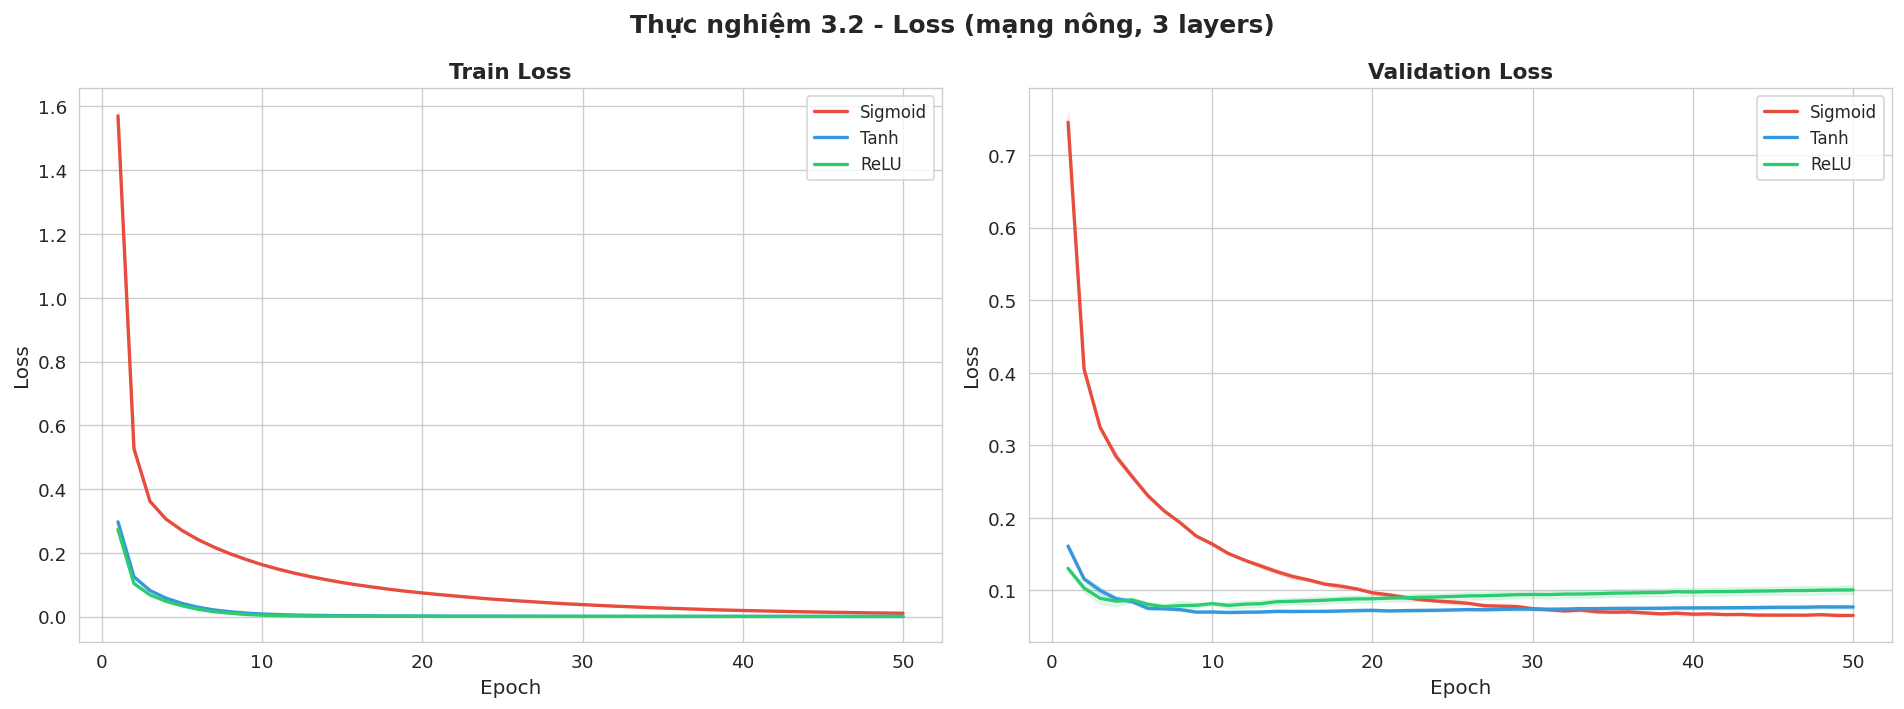

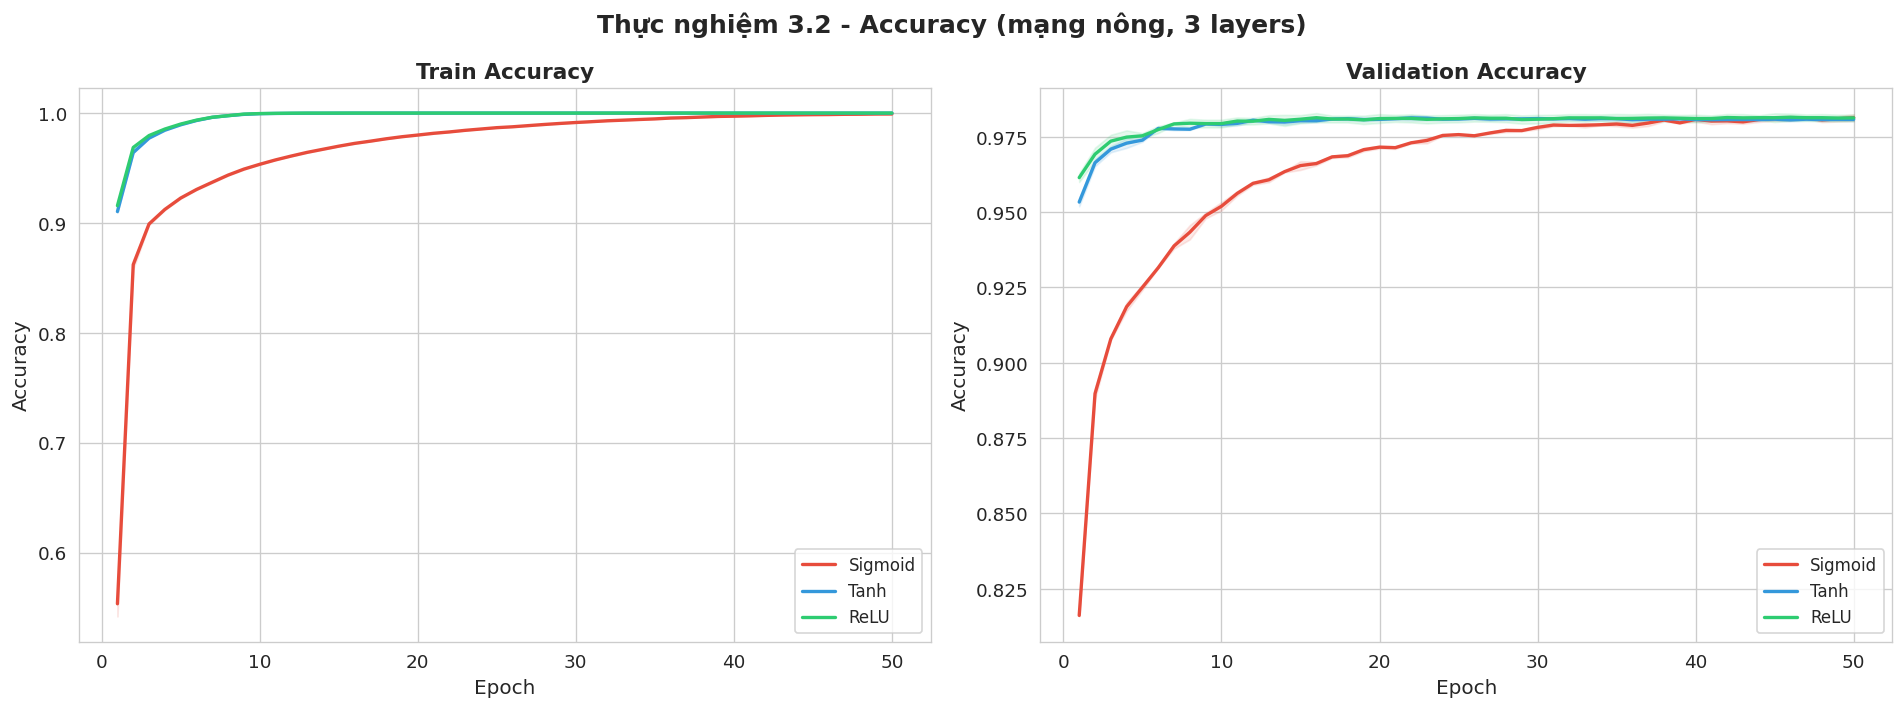

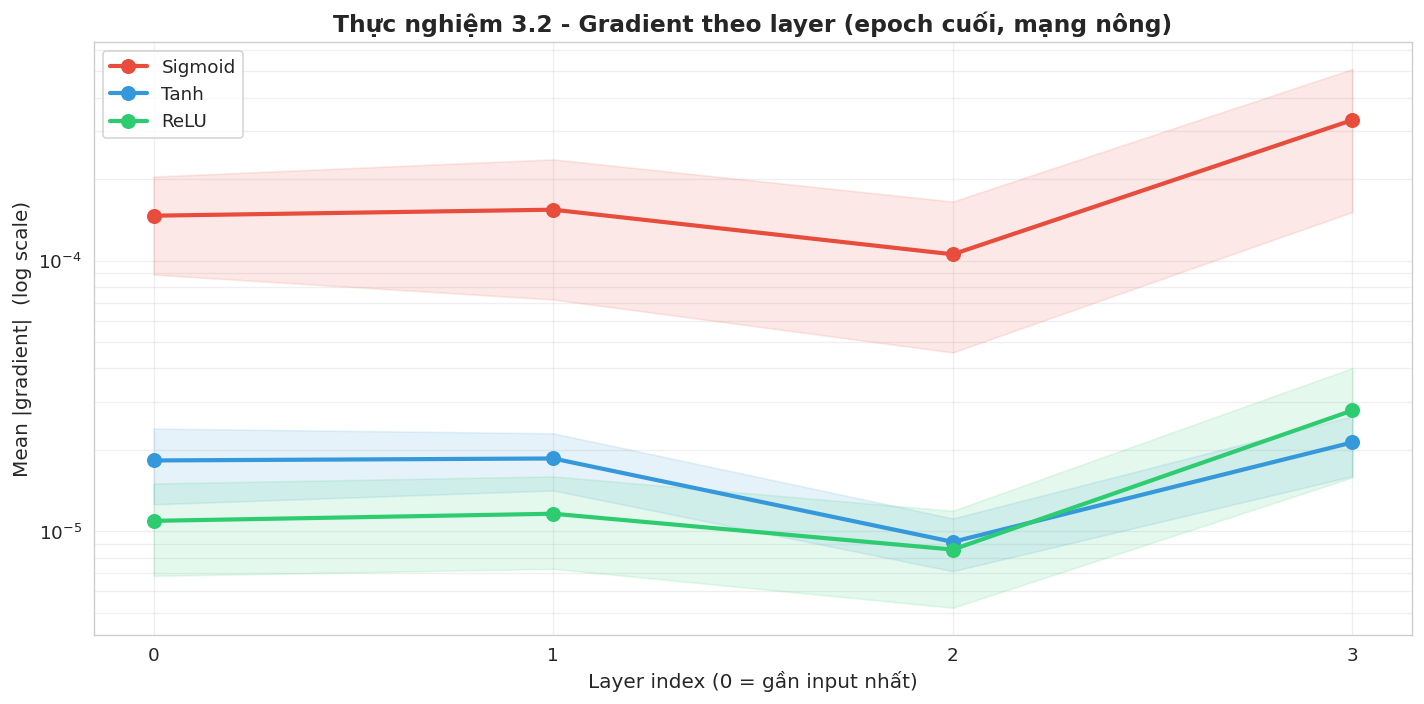



Bảng tổng hợp Thực nghiệm 3.2:


,Activation,Test Acc (%),Final Train Loss,Epoch (95%),Epoch (97%),Epoch (99%),Grad Layer 0
0,Sigmoid,98.02 ± 0.06,0.0103 ± 0.0002,7.0 ± 0.0,10.7 ± 0.5,21.3 ± 2.1,1.47e-04
1,Tanh,97.77 ± 0.05,0.0004 ± 0.0000,1.0 ± 0.0,1.3 ± 0.5,4.0 ± 0.8,1.83e-05
2,ReLU,98.02 ± 0.08,0.0002 ± 0.0000,1.0 ± 0.0,1.0 ± 0.0,3.3 ± 0.5,1.09e-05


In [10]:
plot_loss_curves(results_3_2, title='Thực nghiệm 3.2 - Loss (mạng nông, 3 layers)', save_name='fig_02_expA_loss.png')
plot_accuracy_curves(results_3_2, title='Thực nghiệm 3.2 - Accuracy (mạng nông, 3 layers)', save_name='fig_03_expA_accuracy.png')
plot_gradient_by_layer(results_3_2, epoch_idx=-1, title='Thực nghiệm 3.2 - Gradient theo layer (epoch cuối, mạng nông)', save_name='fig_04_expA_gradient_layer.png')

df_A = create_summary_table(results_3_2)
print('\n\nBảng tổng hợp Thực nghiệm 3.2:')
display(df_A)

### Nhận xét Thực nghiệm 3.2

- **Loss:** Cả 3 hàm kích hoạt đều giảm loss rất tốt. ReLU và Tanh có tốc độ giảm loss cực nhanh và đạt giá trị cuối cùng rất nhỏ (ReLU: 0.0002, Tanh: 0.0004). Hàm Sigmoid có tốc độ giảm loss chậm hơn đáng kể và đạt giá trị cuối cùng ở mức cao hơn (0.0103).
- **Accuracy:** Cả 3 hàm kích hoạt đều đạt độ chính xác kiểm thử (Test Accuracy) rất cao và tương đương nhau (~98% trên mạng nông). Tanh đạt trung bình 97.77%, ReLU đạt trung bình 98.02%, và Sigmoid đạt trung bình 98.02%. Tuy nhiên, Tanh và ReLU có tốc độ hội tụ vượt trội (đạt 95% max acc ngay từ epoch 1.0 và đạt 99% max acc lần lượt ở epoch 4.0 và 3.3). Sigmoid hội tụ chậm hơn nhiều (cần 7.0 epoch để đạt 95% max acc và 21.3 epoch để đạt 99% max acc).
- **Gradient:** Ở kiến trúc mạng nông (3 layers), giá trị trung bình trị tuyệt đối của gradient ở lớp đầu tiên (Layer 0) được bảo toàn ở mức tốt cho cả 3 hàm kích hoạt (Sigmoid: 1.47e-04, Tanh: 1.83e-05, ReLU: 1.09e-05). Hiện tượng triệt tiêu gradient chưa gây ảnh hưởng xấu nghiêm trọng đến việc học của các lớp đầu ở cấu trúc này.
- **Kết luận:** Với mạng nông, sự khác biệt giữa các hàm kích hoạt chủ yếu nằm ở tốc độ hội tụ (ReLU và Tanh hội tụ nhanh hơn gấp khoảng 5-6 lần so với Sigmoid) nhờ tránh được bão hòa đạo hàm ở miền dương hoặc đối xứng qua gốc tọa độ. Độ chính xác cuối cùng của cả 3 hàm không có sự chênh lệch lớn.

## Yêu cầu 4: Yêu cầu mở rộng
### 4.1. Thêm Leaky ReLU vào so sánh, phân tích xem có giải quyết được vấn đề của ReLU thường không

In [11]:
print('THỰC NGHIỆM 4.1: Dying ReLU (Mạng sâu 8 layers)')
# 1. Chạy với Learning Rate chuẩn (0.01)
results_relu_normal = run_multi_seed('ReLU', num_hidden_layers=DEEP_LAYERS, hidden_size=DEEP_HIDDEN, seeds=[42], lr=0.01)
results_leaky_normal = run_multi_seed('Leaky ReLU', num_hidden_layers=DEEP_LAYERS, hidden_size=DEEP_HIDDEN, seeds=[42], lr=0.01)
# 2. Chạy với Learning Rate lớn (0.1) để ép ReLU chết
results_relu_high = run_multi_seed('ReLU', num_hidden_layers=DEEP_LAYERS, hidden_size=DEEP_HIDDEN, seeds=[42], lr=0.1)
results_leaky_high = run_multi_seed('Leaky ReLU', num_hidden_layers=DEEP_LAYERS, hidden_size=DEEP_HIDDEN, seeds=[42], lr=0.1)

results_4_1_lr001 = results_relu_normal + results_leaky_normal
results_4_1_lr01 = results_relu_high + results_leaky_high

THỰC NGHIỆM 4.1: Dying ReLU (Mạng sâu 8 layers)

RELU:
1. 8 layers | hidden=256 | lr=0.01 | seed=42
  Epoch  10/50 | Loss: 0.0144 | Train Acc: 0.9950 | Val Acc: 0.9757
  Epoch  20/50 | Loss: 0.0005 | Train Acc: 0.9999 | Val Acc: 0.9842
  Epoch  30/50 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 0.9850
  Epoch  40/50 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 0.9852
  Epoch  50/50 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 0.9852
  -> Test Acc: 0.9816 | Epoch (95%|97%|99% max_acc): 1|2|5 | Thời gian: 708.1s
--> Trung bình: Test Acc = 0.9816 ± 0.0000 | Epoch (95|97|99) = 1.0|2.0|5.0 | Thời gian = 708.1s

LEAKY RELU:
1. 8 layers | hidden=256 | lr=0.01 | seed=42
  Epoch  10/50 | Loss: 0.0106 | Train Acc: 0.9964 | Val Acc: 0.9780
  Epoch  20/50 | Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 0.9827
  Epoch  30/50 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 0.9832
  Epoch  40/50 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 0.9833
  Epoch  50/50 | Loss: 0.0000 | Train Acc: 1.0000 | Va

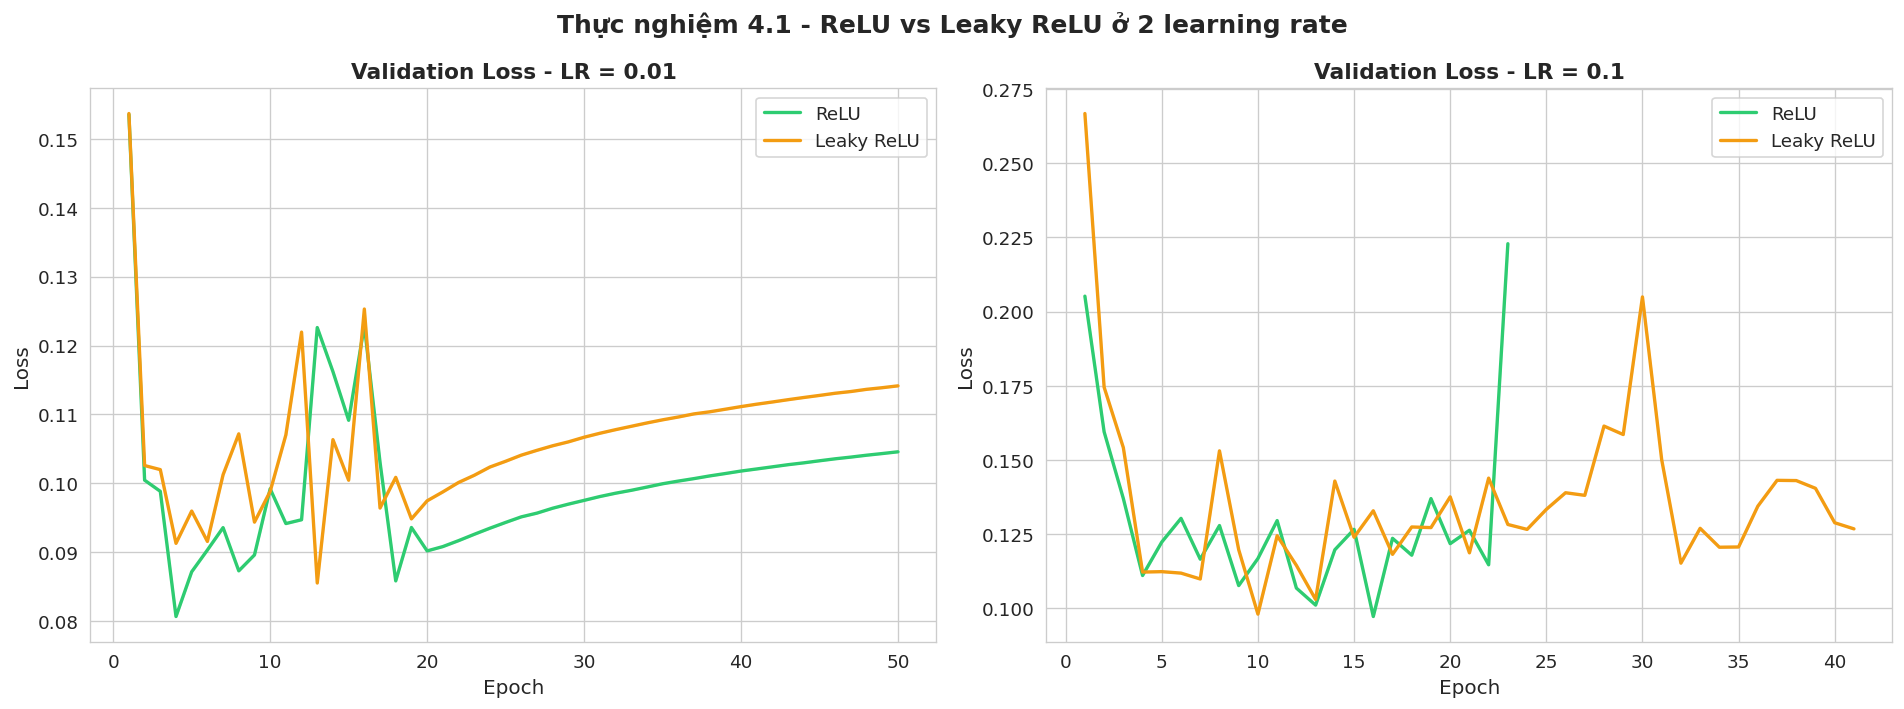

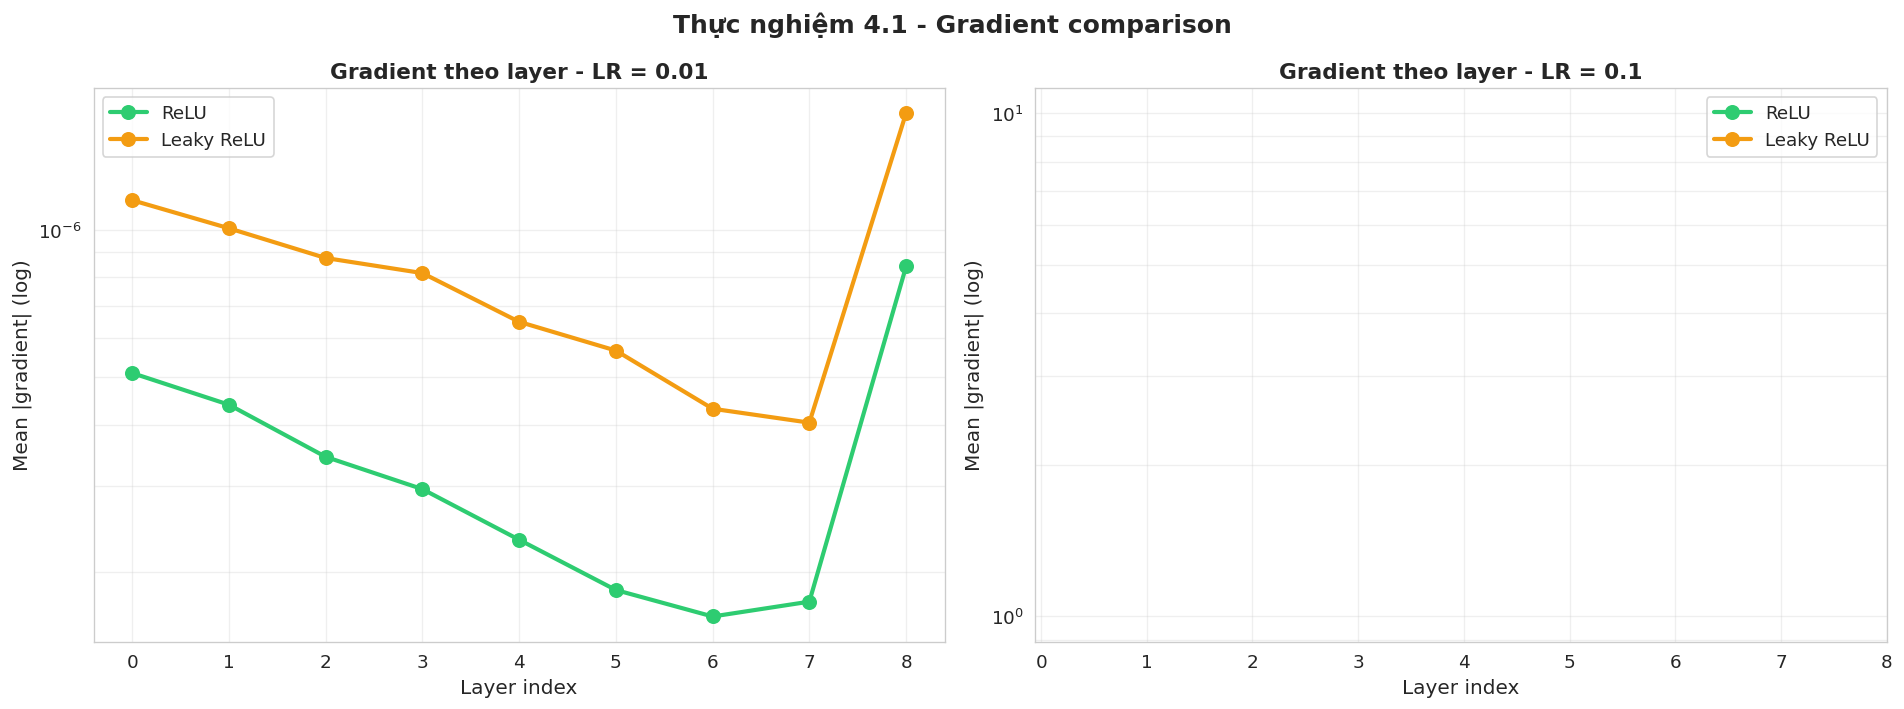

In [12]:
# 1) Loss curve so sánh 2 hàm ở 2 LR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (results, lr_label) in zip(axes, [(results_4_1_lr001, 'LR = 0.01'),(results_4_1_lr01, 'LR = 0.1')]):
    for act_name in ['ReLU', 'Leaky ReLU']:
        act_res = [r for r in results if r['activation'] == act_name]
        color = COLORS[act_name]
        val_arr = np.array([r['history']['val_loss'] for r in act_res])
        epochs_x = np.arange(1, val_arr.shape[1] + 1)
        mean = val_arr.mean(axis=0)
        std  = val_arr.std(axis=0)
        ax.plot(epochs_x, mean, color=color, label=act_name, linewidth=2)
        ax.fill_between(epochs_x, mean - std, mean + std, color=color, alpha=0.12)
    ax.set_title(f'Validation Loss - {lr_label}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=11)

fig.suptitle('Thực nghiệm 4.1 - ReLU vs Leaky ReLU ở 2 learning rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_09_expC_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# 2) Gradient by layer so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (results, lr_label) in zip(axes, [(results_4_1_lr001, 'LR = 0.01'), (results_4_1_lr01,  'LR = 0.1')]):
    for act_name in ['ReLU', 'Leaky ReLU']:
        act_res = [r for r in results if r['activation'] == act_name]
        color = COLORS[act_name]
        all_means = []
        for r in act_res:
            gs = r['history']['gradient_stats'][-1]
            all_means.append([g['mean_abs'] for g in gs])
        all_means = np.array(all_means)
        mean_g = all_means.mean(axis=0)
        layers_x = np.arange(len(mean_g))
        ax.semilogy(layers_x, mean_g, 'o-', color=color, label=act_name, linewidth=2.5, markersize=8)
    ax.set_title(f'Gradient theo layer - {lr_label}', fontweight='bold')
    ax.set_xlabel('Layer index')
    ax.set_ylabel('Mean |gradient| (log)')
    ax.set_xticks(layers_x)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, which='both')

fig.suptitle('Thực nghiệm 4.1 - Gradient comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_expC_gradient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 3) Đếm dead neuron
print('Thống kê neuron chết (dead neuron):\n')

dead_rows = []
for results, lr_label in [(results_4_1_lr001, '0.01'), (results_4_1_lr01,  '0.1')]:
    for r in results:
        ds = count_dead_neurons(r['model'], val_loader, DEVICE)
        dead_rows.append({
            'Activation': r['activation'],
            'LR': lr_label,
            'Seed': r['seed'],
            'Dead Neurons': ds['TOTAL']['dead'],
            'Total Neurons': ds['TOTAL']['total'],
            'Dead %': f"{ds['TOTAL']['pct']:.2f}%",
            'Test Acc (%)': f"{r['test_acc']*100:.2f}",
        })

df_dead = pd.DataFrame(dead_rows)
display(df_dead)

# Tổng hợp mean ± std
print('\n\nTổng hợp (mean ± std):')
summary_rows = []
for act_name in ['ReLU', 'Leaky ReLU']:
    for lr_val in ['0.01', '0.1']:
        subset = df_dead[(df_dead['Activation'] == act_name) & (df_dead['LR'] == lr_val)]
        dead_pcts = subset['Dead Neurons'].values / subset['Total Neurons'].values * 100
        test_accs = subset['Test Acc (%)'].astype(float).values
        summary_rows.append({
            'Activation': act_name,
            'LR': lr_val,
            'Dead %': f'{dead_pcts.mean():.2f} ± {dead_pcts.std():.2f}',
            'Test Acc (%)': f'{test_accs.mean():.2f} ± {test_accs.std():.2f}',
        })

df_C_summary = pd.DataFrame(summary_rows)
display(df_C_summary)

Thống kê neuron chết (dead neuron):



,Activation,LR,Seed,Dead Neurons,Total Neurons,Dead %,Test Acc (%)
0,ReLU,0.01,42,4,2048,0.20%,98.16
1,Leaky ReLU,0.01,42,0,2048,0.00%,98.06
2,ReLU,0.1,42,99,2048,4.83%,9.80
3,Leaky ReLU,0.1,42,0,2048,0.00%,9.80




Tổng hợp (mean ± std):


,Activation,LR,Dead %,Test Acc (%)
0,ReLU,0.01,0.20 ± 0.00,98.16 ± 0.00
1,ReLU,0.1,4.83 ± 0.00,9.80 ± 0.00
2,Leaky ReLU,0.01,0.00 ± 0.00,98.06 ± 0.00
3,Leaky ReLU,0.1,0.00 ± 0.00,9.80 ± 0.00


### Nhận xét Thực nghiệm 4.1

- **Dead neurons:** Ở tốc độ học chuẩn (LR=0.01), ReLU có tỷ lệ nơ-ron chết nhỏ là 0.2% (4/2048 nơ-ron), trong khi Leaky ReLU hoàn toàn không có nơ-ron chết (0.0%). Khi tăng tốc độ học lên mức lớn (LR=0.1) để kích hoạt hiện tượng Dying ReLU, ReLU thuần bị tê liệt nặng với tỷ lệ nơ-ron chết tăng vọt lên 4.83% (99/2048 nơ-ron), trong khi Leaky ReLU vẫn bảo toàn tuyệt đối 0.0% nơ-ron chết.
- **Gradient stability:** Khi LR=0.01, cả hai hàm đều giữ gradient ổn định qua các lớp ẩn. Tuy nhiên, khi LR tăng lên 0.1, do mạng sâu (8 layers) kết hợp tốc độ học quá cao, cả hai mô hình đều gặp hiện tượng bùng nổ hoặc mất ổn định gradient, dẫn đến việc tính toán bị tràn số và giá trị loss nhanh chóng bị bão hòa thành `nan` từ epoch 30 (với ReLU) và epoch 50 (với Leaky ReLU).
-> Đây chính là lý do khiến đồ thị Gradient ở bên phải (phần LR=0.1) hoàn toàn trống trơn. Việc tràn số `nan` khiến thư viện không có dữ liệu số thực nào để biểu diễn. Đồ thị trống này là minh chứng chính xác cho sự sụp đổ của mạng.
- **Accuracy:** Tại tốc độ học chuẩn LR=0.01, cả hai hàm đều hoạt động tốt (ReLU đạt 98.16% và Leaky ReLU đạt 98.06%). Tại LR=0.1, do lỗi tràn số gradient (`nan`), cả hai mô hình đều bị phân rã hoàn toàn và chỉ đạt độ chính xác đoán ngẫu nhiên là 9.80%.
- **Kết luận:** Leaky ReLU đã giải quyết triệt để vấn đề nơ-ron chết (Dying ReLU) nhờ duy trì độ dốc nhỏ (0.01) ở miền âm giúp nơ-ron liên tục nhận được gradient rò rỉ để tự phục hồi. Tuy nhiên, ở các kiến trúc mạng sâu, việc tăng tốc độ học quá cao mà không có các cơ chế chuẩn hóa khác vẫn sẽ gây ra hiện tượng mất ổn định gradient (bùng nổ gradient thành `nan`).

### 4.2. Trực quan hóa phân phối giá trị gradient ở các lớp khác nhau để minh họa trực tiếp hiện tượng vanishing gradient (áp dụng với cả 4 hàm)
*(Cần huấn luyện mạng sâu 8 layers cho cả 4 hàm để quan sát rõ nhất)*

In [14]:
print('THỰC NGHIỆM: Mạng sâu - 8 hidden layers, 4 hàm kích hoạt')
results_deep = []
for act in ['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU']:
    res = run_multi_seed(act, num_hidden_layers=DEEP_LAYERS, hidden_size=DEEP_HIDDEN, seeds=SEEDS, lr=0.01)
    results_deep.extend(res)

THỰC NGHIỆM: Mạng sâu - 8 hidden layers, 4 hàm kích hoạt

SIGMOID:
1. 8 layers | hidden=256 | lr=0.01 | seed=42
  Epoch  10/50 | Loss: 2.3054 | Train Acc: 0.1059 | Val Acc: 0.1055
  Epoch  20/50 | Loss: 2.3030 | Train Acc: 0.1067 | Val Acc: 0.1090
  Epoch  30/50 | Loss: 2.3022 | Train Acc: 0.1111 | Val Acc: 0.1090
  Epoch  40/50 | Loss: 2.3018 | Train Acc: 0.1118 | Val Acc: 0.1090
  Epoch  50/50 | Loss: 2.3017 | Train Acc: 0.1107 | Val Acc: 0.1090
  -> Test Acc: 0.1135 | Epoch (95%|97%|99% max_acc): 2|5|5 | Thời gian: 715.5s
2. 8 layers | hidden=256 | lr=0.01 | seed=123
  Epoch  10/50 | Loss: 2.3057 | Train Acc: 0.1054 | Val Acc: 0.1090
  Epoch  20/50 | Loss: 2.3031 | Train Acc: 0.1085 | Val Acc: 0.1055
  Epoch  30/50 | Loss: 2.3023 | Train Acc: 0.1099 | Val Acc: 0.1090
  Epoch  40/50 | Loss: 2.3018 | Train Acc: 0.1106 | Val Acc: 0.1090
  Epoch  50/50 | Loss: 2.3016 | Train Acc: 0.1114 | Val Acc: 0.1090
  -> Test Acc: 0.1135 | Epoch (95%|97%|99% max_acc): 2|3|3 | Thời gian: 691.8s
3. 8

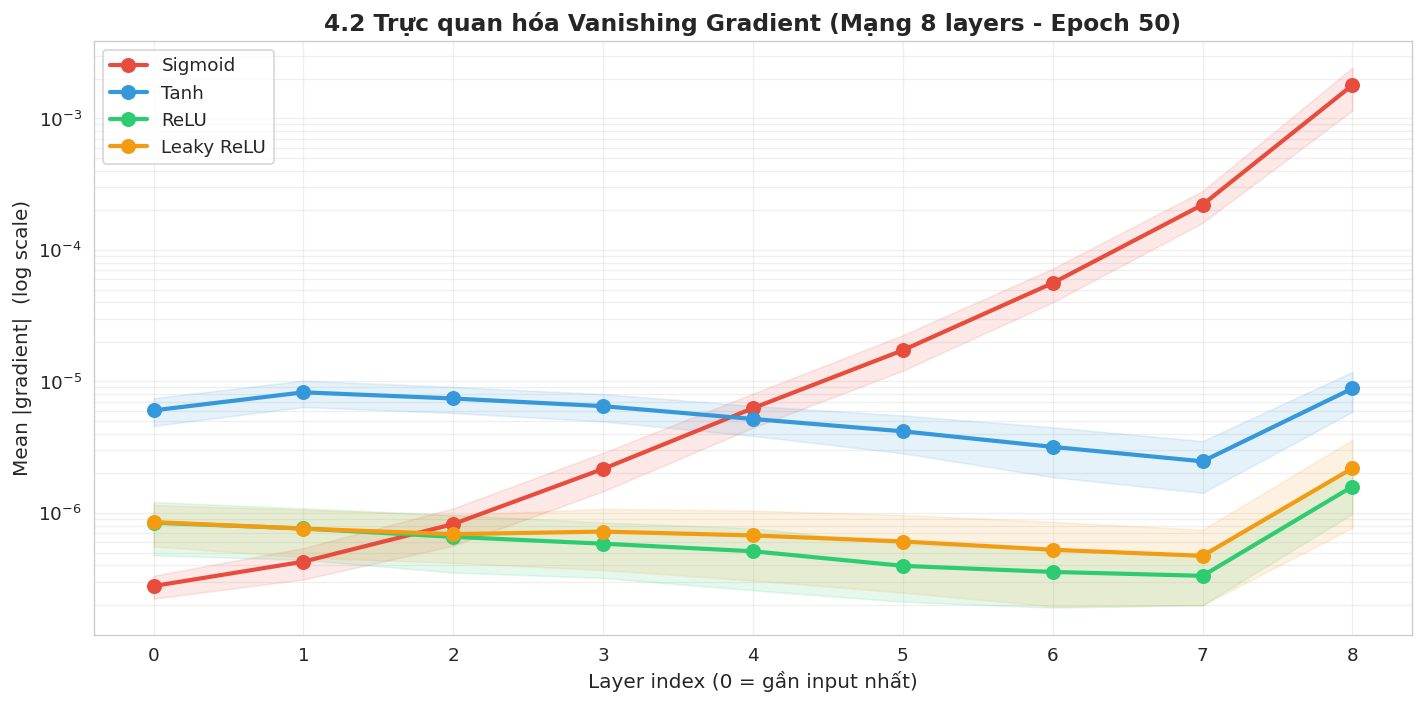

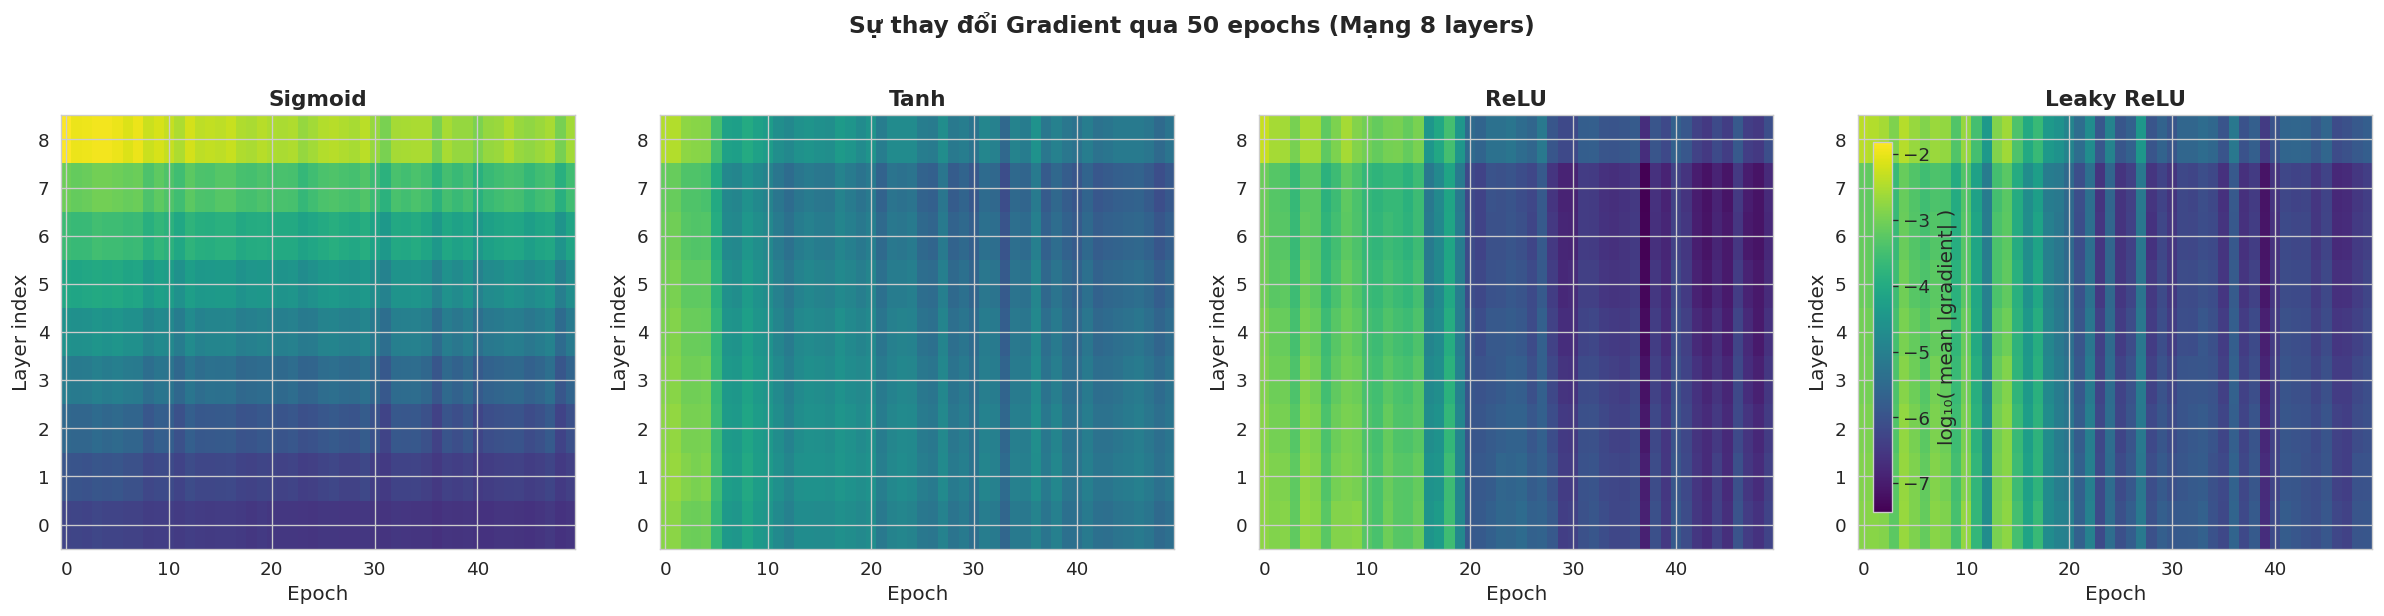

In [15]:
plot_gradient_by_layer(results_deep, epoch_idx=-1, title='4.2 Trực quan hóa Vanishing Gradient (Mạng 8 layers - Epoch 50)', save_name='fig_07_exp42_gradient_layer.png')
plot_gradient_evolution(results_deep, title='Sự thay đổi Gradient qua 50 epochs (Mạng 8 layers)', save_name='fig_08_exp42_gradient_evo.png')

### Nhận xét 4.2
- Nhìn vào biểu đồ đường (bên trái), ở lớp đầu tiên (Layer 0), gradient của Sigmoid và Tanh gần như teo tóp thành 1 vệt rất mỏng, khác biệt một trời một vực so với Layer 7 (lớp cuối). Điều này chứng tỏ lỗi (error) không thể truyền ngược về được các lớp đầu.
- Trong khi đó, gradient của ReLU và Leaky ReLU được bảo toàn cực kỳ tốt, phân bố đều trên tất cả các lớp.

### 4.3. Thử nghiệm trên 2 kiến trúc có độ sâu khác nhau (mạng nông và mạng sâu hơn) để thấy ảnh hưởng của hàm kích hoạt rõ rệt hơn ở mạng sâu
*(So sánh kết quả giữa mục 3.2 (Mạng nông 3 lớp) và mục 4.2 (Mạng sâu 8 lớp)*

In [16]:
print('\nMạng nông (3 layers, hidden=256):')
display(create_summary_table(results_3_2))

print('\n\nMạng sâu (8 layers, hidden=256):')
display(create_summary_table(results_deep))

# So sánh nông vs sâu cho từng activation
print('\n\nSo sánh Mạng nông vs Mạng sâu:')
compare_rows = []
for act_name in ['Sigmoid', 'Tanh', 'ReLU']:
    a_res = [r for r in results_3_2 if r['activation'] == act_name]
    b_res = [r for r in results_deep if r['activation'] == act_name]

    a_acc = np.mean([r['test_acc'] for r in a_res]) * 100
    b_acc = np.mean([r['test_acc'] for r in b_res]) * 100

    a_grad0 = np.mean([r['history']['gradient_stats'][-1][0]['mean_abs'] for r in a_res])
    b_grad0 = np.mean([r['history']['gradient_stats'][-1][0]['mean_abs'] for r in b_res])

    compare_rows.append({
        'Activation': act_name,
        'Acc Nông (%)': f'{a_acc:.2f}',
        'Acc Sâu (%)':  f'{b_acc:.2f}',
        'Δ Acc (%)':    f'{b_acc - a_acc:+.2f}',
        'Grad₀ Nông':   f'{a_grad0:.2e}',
        'Grad₀ Sâu':    f'{b_grad0:.2e}',
    })
df_compare = pd.DataFrame(compare_rows)
display(df_compare)


Mạng nông (3 layers, hidden=256):


,Activation,Test Acc (%),Final Train Loss,Epoch (95%),Epoch (97%),Epoch (99%),Grad Layer 0
0,Sigmoid,98.02 ± 0.06,0.0103 ± 0.0002,7.0 ± 0.0,10.7 ± 0.5,21.3 ± 2.1,1.47e-04
1,Tanh,97.77 ± 0.05,0.0004 ± 0.0000,1.0 ± 0.0,1.3 ± 0.5,4.0 ± 0.8,1.83e-05
2,ReLU,98.02 ± 0.08,0.0002 ± 0.0000,1.0 ± 0.0,1.0 ± 0.0,3.3 ± 0.5,1.09e-05




Mạng sâu (8 layers, hidden=256):


,Activation,Test Acc (%),Final Train Loss,Epoch (95%),Epoch (97%),Epoch (99%),Grad Layer 0
0,Sigmoid,11.35 ± 0.00,2.3016 ± 0.0000,1.7 ± 0.5,4.0 ± 0.8,4.0 ± 0.8,2.78e-07
1,Tanh,97.83 ± 0.02,0.0001 ± 0.0000,1.0 ± 0.0,1.0 ± 0.0,3.3 ± 0.5,6.03e-06
2,ReLU,98.21 ± 0.04,0.0000 ± 0.0000,1.0 ± 0.0,1.7 ± 0.5,5.3 ± 0.5,8.44e-07
3,Leaky ReLU,98.19 ± 0.10,0.0000 ± 0.0000,1.0 ± 0.0,1.3 ± 0.5,5.7 ± 2.1,8.53e-07




So sánh Mạng nông vs Mạng sâu:


,Activation,Acc Nông (%),Acc Sâu (%),Δ Acc (%),Grad₀ Nông,Grad₀ Sâu
0,Sigmoid,98.02,11.35,-86.67,1.47e-04,2.78e-07
1,Tanh,97.77,97.83,+0.05,1.83e-05,6.03e-06
2,ReLU,98.02,98.21,+0.19,1.09e-05,8.44e-07


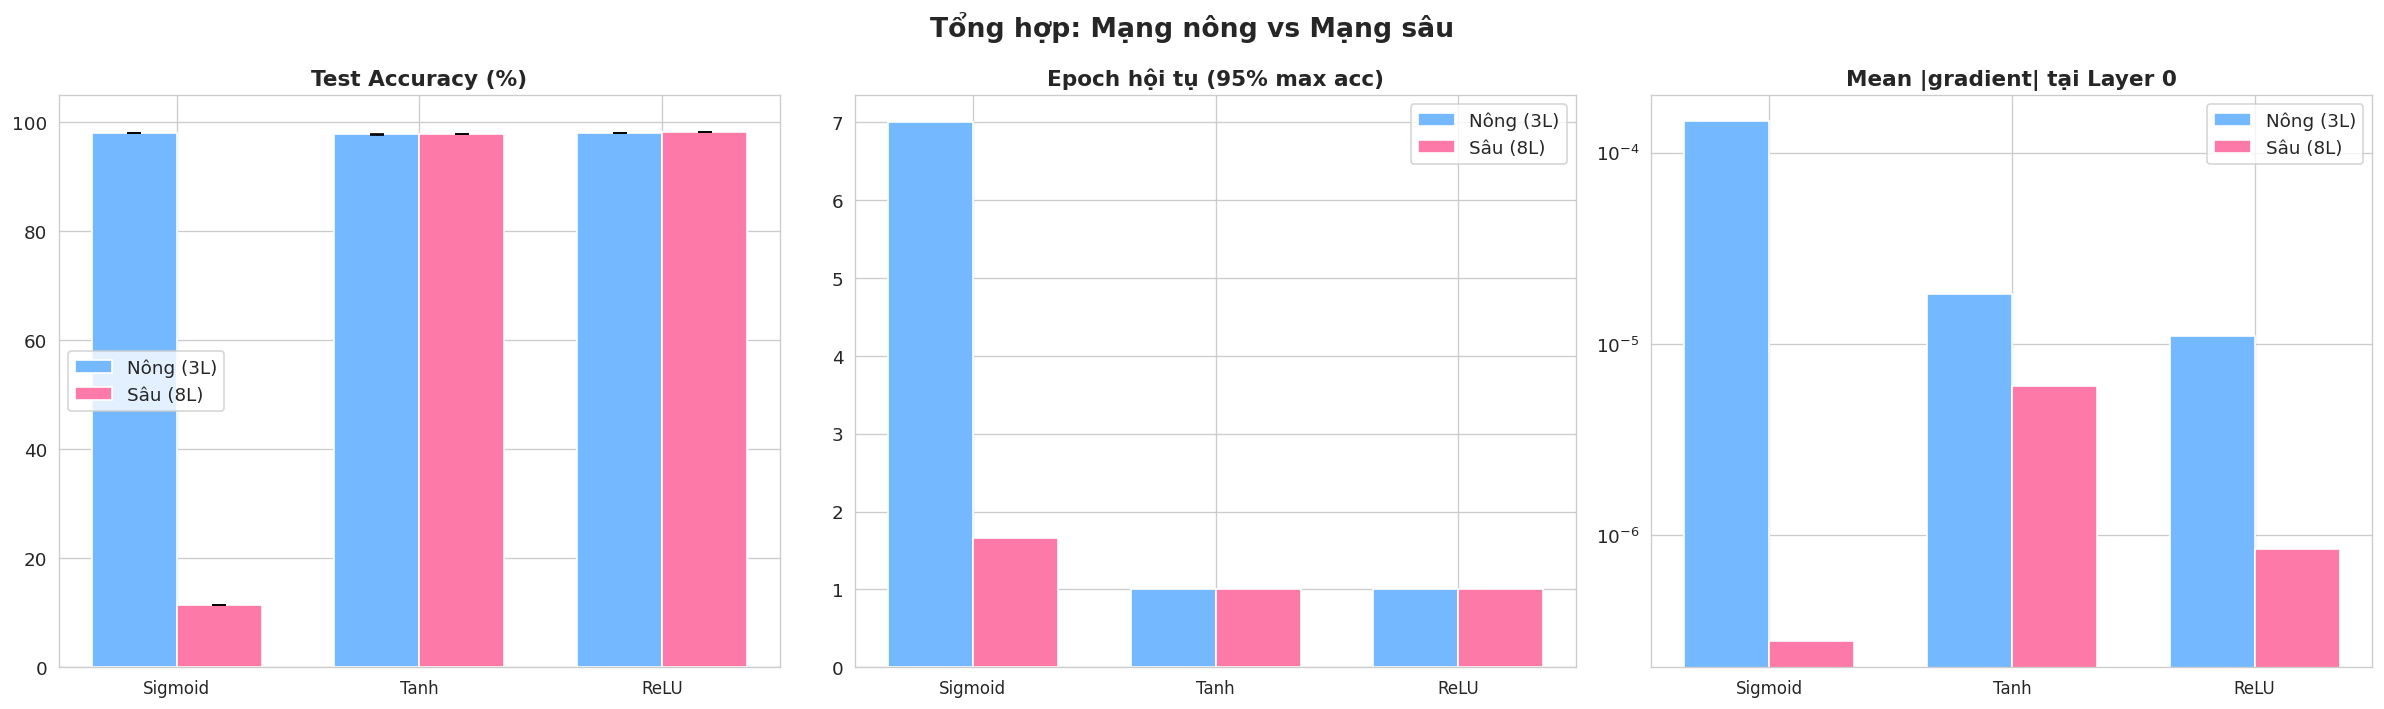

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

act_names = ['Sigmoid', 'Tanh', 'ReLU']
x_pos = np.arange(len(act_names))
width = 0.35

# 1) Test Accuracy
acc_A = [np.mean([r['test_acc'] for r in results_3_2 if r['activation'] == a]) * 100 for a in act_names]
acc_B = [np.mean([r['test_acc'] for r in results_deep if r['activation'] == a]) * 100 for a in act_names]
std_A = [np.std([r['test_acc'] for r in results_3_2 if r['activation'] == a]) * 100 for a in act_names]
std_B = [np.std([r['test_acc'] for r in results_deep if r['activation'] == a]) * 100 for a in act_names]

bars1 = axes[0].bar(x_pos - width/2, acc_A, width, yerr=std_A, label='Nông (3L)', color='#74b9ff', capsize=4)
bars2 = axes[0].bar(x_pos + width/2, acc_B, width, yerr=std_B, label='Sâu (8L)', color='#fd79a8', capsize=4)
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(act_names, fontsize=10)
axes[0].legend()
axes[0].set_ylim(0, 105)

# 2) Convergence Epoch
conv_A = [np.mean([r['conv_95'] for r in results_3_2 if r['activation'] == a]) for a in act_names]
conv_B = [np.mean([r['conv_95'] for r in results_deep if r['activation'] == a]) for a in act_names]

axes[1].bar(x_pos - width/2, conv_A, width, label='Nông (3L)', color='#74b9ff')
axes[1].bar(x_pos + width/2, conv_B, width, label='Sâu (8L)', color='#fd79a8')
axes[1].set_title('Epoch hội tụ (95% max acc)', fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(act_names, fontsize=10)
axes[1].legend()

# 3) Gradient tại layer đầu
grad_A = [np.mean([r['history']['gradient_stats'][-1][0]['mean_abs'] for r in results_3_2 if r['activation'] == a]) for a in act_names]
grad_B = [np.mean([r['history']['gradient_stats'][-1][0]['mean_abs'] for r in results_deep if r['activation'] == a]) for a in act_names]

axes[2].bar(x_pos - width/2, grad_A, width, label='Nông (3L)', color='#74b9ff')
axes[2].bar(x_pos + width/2, grad_B, width, label='Sâu (8L)', color='#fd79a8')
axes[2].set_title('Mean |gradient| tại Layer 0', fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(act_names, fontsize=10)
axes[2].set_yscale('log')
axes[2].legend()

fig.suptitle('Tổng hợp: Mạng nông vs Mạng sâu', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

| Tình huống | Hàm kích hoạt khuyến nghị | Lý do |
|-----------|--------------------------|-------|
| Mạng nông (< 5 layers) | ReLU hoặc Tanh | Vanishing gradient chưa nghiêm trọng |
| Mạng sâu (> 5 layers) | ReLU hoặc Leaky ReLU | Sigmoid/Tanh bị vanishing gradient |
| Mạng sâu + LR cao | Leaky ReLU | Tránh dying ReLU |
| Cần output bounded | Sigmoid (0,1) hoặc Tanh (-1,1) | Đặc thù bài toán |